<a href="https://colab.research.google.com/github/shrey9903/Retail_Sales_Data_Analyzer-/blob/main/retail_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os


# Class Definition
class RetailAnalyzer:
  """ Retail Sales Data Analyzer """

  # Constructor

  def __init__(self):
    self.df = None    # Initializes the dataframe variable


  # Loading Data
  def load_data(self, file_path):

    # Read CSV file
    self.df = pd.read_csv(file_path)

    # Converting date to datetime
    self.df['date'] = pd.to_datetime(self.df['date'])

    # Remove missing values if present
    if self.df.isnull().values.any():
      self.df = self.df.dropna()

    print("Data loaded!")


  # Calculate Metrics
  def calculate_meyrices(self):

    # total sales
    total_sales = np.sum(self.df['total_sales'])

    # average sales
    avg_sales = np.mean(self.df['total_sales'])

    # top selling product
    top_product = self.df.groupby('product')['total_sales'].sum().idxmax()

    print("Sales report of sale")

    print("Total Sales:", total_sales)
    print("Average Sales:", avg_sales)
    print("Top Product:", top_product)

  # Filter Data

  def filter_data(self, condition):

    filtered_data = self.df.query(condition)

    print("Filtered!")

    return filtered_data


  # Display Summary
  def display_summary(self):

    # Display dataset structure
    print(" Dataset Information ")
    print(self.df.info())

    # Display statistical summary
    print("\n Dataset Description")
    print(self.df.describe())

  # Visualization Section
  def visualize_data(self):

    sns.set(style="whitegrid")

    # figure provided with size
    plt.figure(figsize=(18,6))

    # Bar Chart: Revenue by Product
    plt.subplot(1,3,1)

    sales = self.df.groupby('product')['total_sales'].sum()
    sns.barplot(x=sales.index, y=sales.values)

    plt.title("Revenue by Product")
    plt.xlabel("Product")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)

    # Line Chart: Daily Sales Trend
    plt.subplot(1,3,2)

    trend = self.df.groupby('date')['total_sales'].sum().reset_index()
    sns.lineplot(data=trend, x='date', y='total_sales', marker='o')

    plt.title("Daily Sales Trend")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.xticks(rotation=45)


    # Heatmap: Correlation Analysis
    plt.subplot(1,3,3)

    corr = self.df[['price','quantity_sold','total_sales']].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm")

    plt.title("Correlation Heatmap")


    # Display all plots
    plt.show()


Data loaded!
 Dataset Information 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           50 non-null     datetime64[ns]
 1   product        50 non-null     object        
 2   category       50 non-null     object        
 3   price          50 non-null     int64         
 4   quantity_sold  50 non-null     int64         
 5   total_sales    50 non-null     int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 2.5+ KB
None

 Dataset Description
                      date       price  quantity_sold   total_sales
count                   50   50.000000      50.000000     50.000000
mean   2026-01-25 12:00:00  244.000000      15.660000   4132.800000
min    2026-01-01 00:00:00   25.000000       1.000000     40.000000
25%    2026-01-13 06:00:00   50.000000       9.250000    602.500000
50%    2026-01-25 1

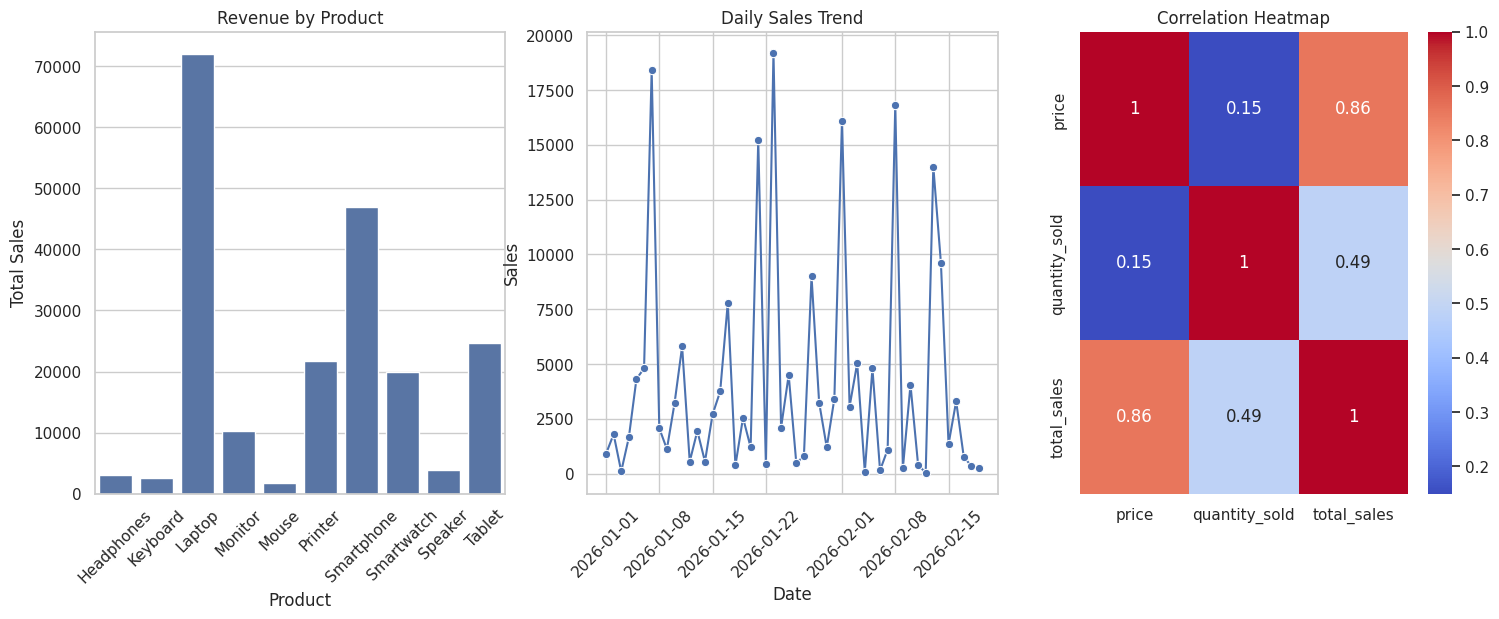

In [45]:
# sample calling of all functions which can be checked

app = RetailAnalyzer()

app.load_data("/content/retail_sales_sample.csv")
app.display_summary()
app.calculate_meyrices()
app.visualize_data()


In [18]:
df

,date,product,category,price,quantity_sold,total_sales
0,2026-01-01,Smartwatch,Wearables,180,5,900
1,2026-01-02,Speaker,Accessories,90,20,1800
2,2026-01-03,Mouse,Accessories,25,4,100
3,2026-01-04,Printer,Electronics,150,11,1650
4,2026-01-05,Smartwatch,Wearables,180,24,4320
5,2026-01-06,Laptop,Electronics,800,6,4800
6,2026-01-07,Laptop,Electronics,800,23,18400
7,2026-01-08,Speaker,Accessories,90,23,2070
8,2026-01-09,Keyboard,Accessories,40,28,1120
9,2026-01-10,Monitor,Electronics,200,16,3200
